# CNN

In [39]:
# Special layer + ANN
# Special layers : Convolutional layer, Pooling layer
# Convolutional Layer : To find the features in image with the help of Kernel
# Pooling layer : To reduce the dimension of image while preserving important feature
# Padding : We add one layer of ZERO's around the image matrix. 
# Padding: It will help to preserve the boundary of image
# Stride : How many steps we are moving the window (Row or Column)

In [40]:
import tensorflow as tf
from tensorflow import keras

from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras.models import Sequential

In [41]:
# CIFAR10 dataset
(x_train,y_train),(x_test, y_test) = keras.datasets.cifar10.load_data()

In [42]:
x_train.shape

(50000, 32, 32, 3)

In [43]:
x_test.shape

(10000, 32, 32, 3)

In [44]:
x_train[1]

array([[[154, 177, 187],
        [126, 137, 136],
        [105, 104,  95],
        ...,
        [ 91,  95,  71],
        [ 87,  90,  71],
        [ 79,  81,  70]],

       [[140, 160, 169],
        [145, 153, 154],
        [125, 125, 118],
        ...,
        [ 96,  99,  78],
        [ 77,  80,  62],
        [ 71,  73,  61]],

       [[140, 155, 164],
        [139, 146, 149],
        [115, 115, 112],
        ...,
        [ 79,  82,  64],
        [ 68,  70,  55],
        [ 67,  69,  55]],

       ...,

       [[175, 167, 166],
        [156, 154, 160],
        [154, 160, 170],
        ...,
        [ 42,  34,  36],
        [ 61,  53,  57],
        [ 93,  83,  91]],

       [[165, 154, 128],
        [156, 152, 130],
        [159, 161, 142],
        ...,
        [103,  93,  96],
        [123, 114, 120],
        [131, 121, 131]],

       [[163, 148, 120],
        [158, 148, 122],
        [163, 156, 133],
        ...,
        [143, 133, 139],
        [143, 134, 142],
        [143, 133, 144]]

In [45]:
print(y_train[1][0])

9


In [46]:
class_names = ['airplane', 'automobile', 'bird', 'cat ', 'deer', 'dog', 'frog' , 'horse' , 'ship' ,'truck']
class_names[y_train[49999][0]]

'automobile'

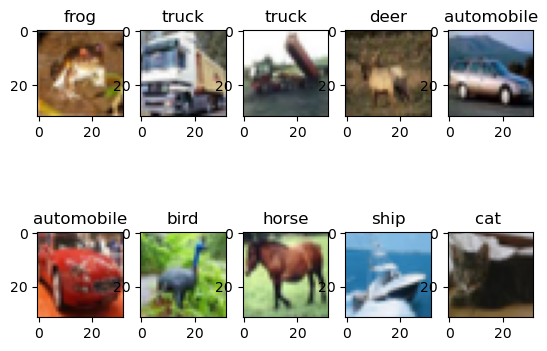

In [47]:
import matplotlib.pyplot as plt
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])

In [48]:
# Scaling of data (0 to 1)
x_train, x_test = x_train/255.0, x_test/255.0
x_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [49]:
# Build the model
model = Sequential([
                    Input(shape = (32, 32, 3)),
                    Conv2D(32, (3,3), activation = 'relu'),
                    MaxPooling2D(2,2),
                    Flatten(),
                    Dense(128, activation = 'relu'),
                    Dense(10, activation = 'softmax')
])

In [56]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [57]:
x_test.shape

(10000, 32, 32, 3)

In [58]:
history = model.fit(x_train, y_train, epochs = 2)

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.4696 - loss: 1.4809
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5777 - loss: 1.2062


In [59]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5905 - loss: 1.1669   
0.590499997138977


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


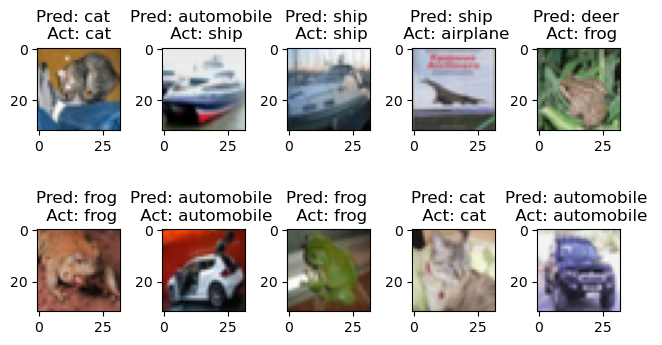

In [76]:
# predicted vs Actual
import numpy as np

for i in range(10):
    img = x_test[i]  # (32, 32, 3)
    img_expand = np.expand_dims(img, axis = 0)  # (1, 32, 32, 3)
    pred = model.predict(img_expand)
    pred_label = np.argmax(pred)
    plt.subplot(2,5, i+1)
    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred_label]} \n Act: {class_names[y_test[i][0]]}")
    plt.tight_layout()